# Detekcja mowy nienawiści | Model Zaawansowany

In [2]:
import tensorflow as tf

In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

In [4]:
train_data = pd.read_csv("../data/df_train.csv")
val_data = pd.read_csv("../data/df_val.csv")
test_data = pd.read_csv("../data/df_test.csv")
train_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,7ca72b5b9c688e9e,"Geez, are you forgetful! We've already discus...",0,0,0,0,0,0
1,c03f72fd8f8bf54f,Carioca RFA \r\n\r\nThanks for your support on...,0,0,0,0,0,0
2,9e5b8e8fc1ff2e84,"""\r\n\r\n Birthday \r\n\r\nNo worries, It's wh...",0,0,0,0,0,0
3,5332799e706665a6,Pseudoscience category? \r\n\r\nI'm assuming t...,0,0,0,0,0,0
4,dfa7d8f0b4366680,"(and if such phrase exists, it would be provid...",0,0,0,0,0,0


In [5]:
severeToxic = train_data["severe_toxic"] + train_data["threat"] + train_data["identity_hate"]
severeToxic[severeToxic == 1] = 2
severeToxic[severeToxic > 3] = 2

In [6]:
basicToxic = train_data["toxic"] + train_data["obscene"] + train_data["insult"]
basicToxic[basicToxic > 1] = 1
basicToxic[severeToxic == 2] = 2

In [7]:
clean_train = pd.DataFrame([train_data["comment_text"], basicToxic], ["comment", "toxicLevel"]).T

In [8]:
def column_collapse(df):
    severeToxic = df["severe_toxic"] + df["threat"] + df["identity_hate"]
    genToxic = df["toxic"] + df["obscene"] + df["insult"]
    genToxic[genToxic > 1] = 1
    genToxic[severeToxic > 0] = 2

    return pd.DataFrame([df["comment_text"], genToxic], ["comment", "toxicLevel"]).T

In [9]:
clean_train = column_collapse(train_data)
clean_val = column_collapse(val_data)
clean_test = column_collapse(test_data)

In [10]:
tftrain = clean_train.map(tf.convert_to_tensor)

In [11]:
clean_test.head()

,comment,toxicLevel
0,"""\r\n\r\nAside from failing to provide a sourc...",0
1,"""\r\n\r\n Sourcing of """"most decorated"""" Audie...",0
2,I like the term Eastern Eurasian better than M...,0
3,"Hmmm... No, you have to compare the 2005 rati...",0
4,The monument referred to in the article is thi...,0


In [12]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '\n', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [13]:
max_features = 100000
sequence_length = 1024

vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [14]:
train_text = clean_train["comment"]
vectorize_layer.adapt(train_text)

In [15]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [18]:
example = clean_train["comment"][21]

print(f"Komentarz: {example}")
print(f"Toxic level", clean_train["toxicLevel"][21])
tf.print(vectorize_text(example, clean_train["toxicLevel"][21]), summarize=-1)

Komentarz: no worries 

We will use another account, and will not stop until wikipedia stops pushing the evil, sin filled gay agenda
Toxic level 2
([[47 4341 65 48 83 189 373 6 48 15 167 364 37 7257 1671 2 1812 5359 3126 818 1815 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [21]:
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

Vocabulary size: 63989


In [22]:
def tensorflowify (pandaset):
    tensored = pandaset.map(tf.convert_to_tensor)
    applied = tensored.apply(lambda x: vectorize_text(x[0], x[1]), axis=1)
    listed = list(applied)

    features = [x for x, y in listed]
    labels   = [y for x, y in listed]

    return tf.data.Dataset.from_tensor_slices((features, labels))

In [23]:
train_ds = tensorflowify(clean_train)
val_ds = tensorflowify(clean_val)
test_ds = tensorflowify(clean_test)

C:\Users\tomas\AppData\Local\Temp\ipykernel_13372\505999176.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  applied = tensored.apply(lambda x: vectorize_text(x[0], x[1]), axis=1)


In [24]:
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)
val_ds  = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [26]:
embedding_dim = 16

In [27]:
from tensorflow.keras import layers
from tensorflow.keras import losses

In [107]:
model = tf.keras.Sequential([
  layers.Input(shape=(1, 1024,), dtype=tf.int32),
  # layers.Lambda(lambda x: tf.squeeze(x, axis=1)),
  layers.Embedding(max_features, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling2D(),
  layers.Dropout(0.2),
  layers.Dense(1, activation='sigmoid')])

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 1, 1024, 16)    │     1,600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 1024, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,600,017 (6.10 MB)

 Trainable params: 1,600,017 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model.compile(loss=losses.MeanAbsoluteError(),
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.4)])

In [109]:
epochs = 3
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - binary_accuracy: 0.8988 - loss: 0.1209 - val_binary_accuracy: 0.9010 - val_loss: 0.1187
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - binary_accuracy: 0.9003 - loss: 0.1179 - val_binary_accuracy: 0.9015 - val_loss: 0.1185
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - binary_accuracy: 0.9003 - loss: 0.1177 - val_binary_accuracy: 0.9015 - val_loss: 0.1183


In [93]:
for x, y in train_ds.take(1):
    print("X batch shape:", x.shape)
    print("y batch shape:", y.shape)

X batch shape: (32, 1, 1024)
y batch shape: (32,)


In [97]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8946 - loss: 0.1278
Loss:  0.12783102691173553
Accuracy:  0.894599974155426


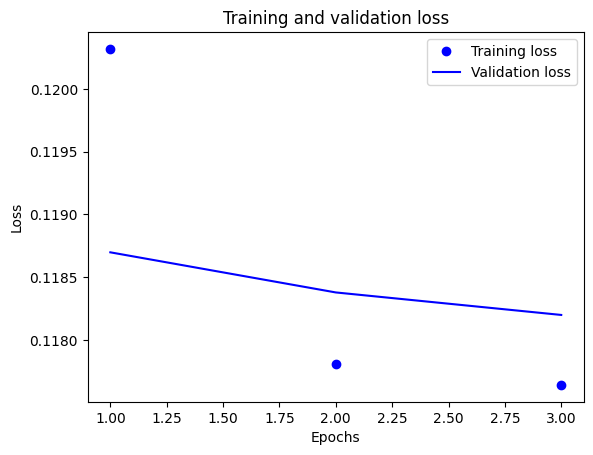

In [98]:
history_dict = history.history
history_dict.keys()
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 2. XGBoost

In [ ]:
GlobalAveragePooling1D